## 1. Cost Function
* Definition: A mathematical function that measures the overall error or difference between a model's predictions and the true target values across a dataset.
* Use Cases:
    * Quantifying model performance and guiding optimization algorithms during training.
* Pros:
    * Summarizes total model error into a single scalar value; differentiable for optimization.
* Cons:
    * Non-convex cost functions can feature multiple local minima, complicating optimization.

### Visualizing a Quadratic Cost Function

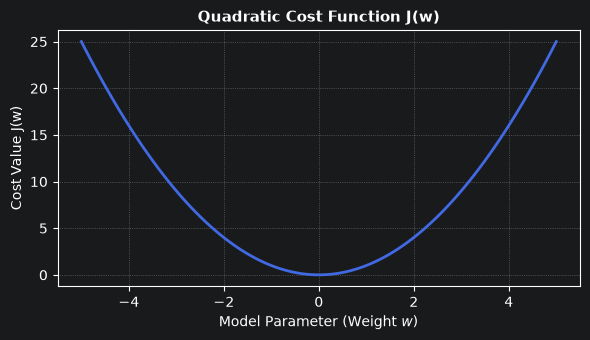

In [1]:
import numpy as np
import matplotlib.pyplot as plt

w = np.linspace(-5, 5, 100)
cost = w ** 2

plt.figure(figsize=(6, 3.5))
plt.plot(w, cost, color='royalblue', linewidth=2)
plt.title("Quadratic Cost Function J(w)", fontsize=11, fontweight='bold')
plt.xlabel("Model Parameter (Weight $w$)")
plt.ylabel("Cost Value J(w)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 2. Gradient
* Definition: A vector of partial derivatives pointing in the direction of the greatest rate of increase of the cost function.
* Use Cases:
    * Determining the slope and rate of change to guide parameter updates.
* Pros:
    * Mathematically precise indicator of how individual weights impact total error.
* Cons:
    * Computationally expensive to calculate over massive neural network architectures without automatic differentiation.

### Visualizing Gradient (Slope) on a Cost Curve

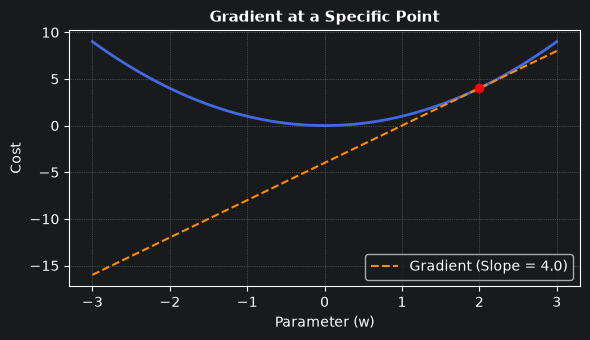

In [2]:
import numpy as np
import matplotlib.pyplot as plt

w = np.linspace(-3, 3, 100)
cost = w ** 2

# Point of interest
w_val = 2.0
cost_val = w_val ** 2
slope = 2 * w_val # derivative of w^2

plt.figure(figsize=(6, 3.5))
plt.plot(w, cost, color='royalblue', linewidth=2)
plt.scatter([w_val], [cost_val], color='red', zorder=5)
# Tangent line: y - y1 = m(x - x1)
tangent = cost_val + slope * (w - w_val)
plt.plot(w, tangent, color='darkorange', linestyle='--', label=f"Gradient (Slope = {slope})")

plt.title("Gradient at a Specific Point", fontsize=11, fontweight='bold')
plt.xlabel("Parameter (w)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Learning Direction
* Definition: The negative of the gradient vector, which points directly toward the steepest descent to minimize the cost function.
* Use Cases:
    * Guiding weight adjustments ($w = w - \alpha \cdot \text{gradient}$) to reduce model error.
* Pros:
    * Ensures steady movement toward lower error and minimum convergence.
* Cons:
    * Can cause severe oscillations or slow progress if the error landscape is ill-conditioned (ravines).

### Visualizing Learning Direction (Steepest Descent)

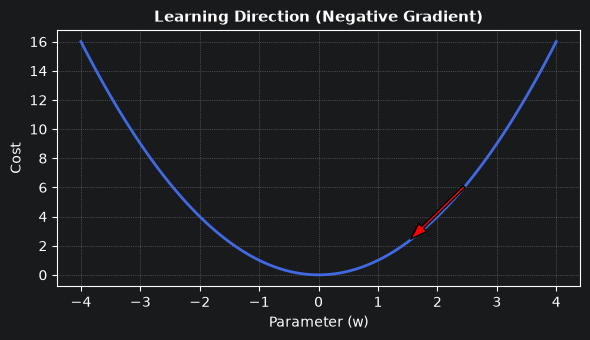

In [3]:
import numpy as np
import matplotlib.pyplot as plt

w = np.linspace(-4, 4, 100)
cost = w ** 2

plt.figure(figsize=(6, 3.5))
plt.plot(w, cost, color='royalblue', linewidth=2)
# Annotate descent direction
plt.annotate('', xy=(1.5, 2.25), xytext=(2.5, 6.25),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8))
plt.title("Learning Direction (Negative Gradient)", fontsize=11, fontweight='bold')
plt.xlabel("Parameter (w)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Batch Gradient Descent
* Definition: An optimization algorithm that computes the gradient of the cost function using the entire dataset for a single parameter update.
* Use Cases:
    * Small datasets or convex optimization problems requiring stable updates.
* Pros:
    * Guaranteed convergence to the global minimum for convex functions with a smooth trajectory.
* Cons:
    * Extremely slow and memory-intensive when processing large-scale datasets.

### Visualizing Batch Gradient Descent Trajectory

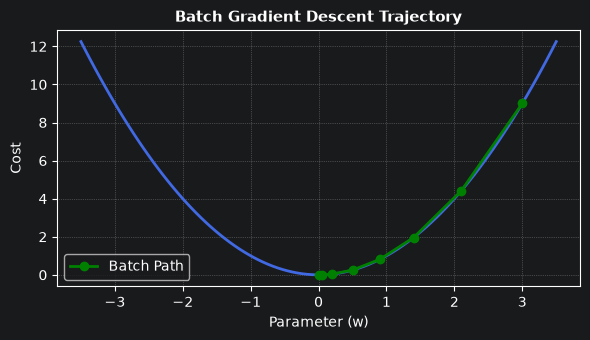

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulating smooth, direct convergence path
steps_w = np.array([3.0, 2.1, 1.4, 0.9, 0.5, 0.2, 0.05, 0.0])
steps_cost = steps_w ** 2

plt.figure(figsize=(6, 3.5))
w = np.linspace(-3.5, 3.5, 100)
plt.plot(w, w**2, color='royalblue', linewidth=2)
plt.plot(steps_w, steps_cost, marker='o', color='green', linestyle='-', linewidth=2, label="Batch Path")
plt.title("Batch Gradient Descent Trajectory", fontsize=11, fontweight='bold')
plt.xlabel("Parameter (w)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Stochastic Gradient Descent (SGD)
* Definition: An optimization algorithm that updates model parameters using the gradient computed from only a single randomly chosen sample at a time.
* Use Cases:
    * Massive datasets and online learning streams where data arrives continuously.
* Pros:
    * Extremely fast per iteration; noisy updates help the model jump out of shallow local minima.
* Cons:
    * High variance causes erratic, noisy oscillations around the minimum instead of a smooth descent.

### Visualizing Stochastic Gradient Descent (SGD) Path

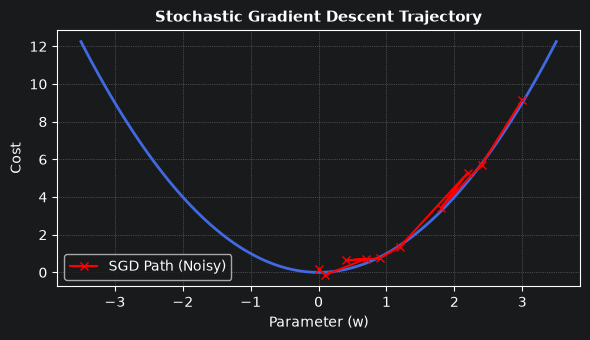

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
# Simulating a noisy, erratic convergence path
steps_w = np.array([3.0, 2.4, 1.8, 2.2, 1.2, 0.9, 0.4, 0.7, 0.1, 0.0])
steps_cost = steps_w ** 2 + np.random.normal(0, 0.3, len(steps_w))

plt.figure(figsize=(6, 3.5))
w = np.linspace(-3.5, 3.5, 100)
plt.plot(w, w**2, color='royalblue', linewidth=2)
plt.plot(steps_w, steps_cost, marker='x', color='red', linestyle='-', linewidth=1.5, label="SGD Path (Noisy)")
plt.title("Stochastic Gradient Descent Trajectory", fontsize=11, fontweight='bold')
plt.xlabel("Parameter (w)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Mini-Batch Gradient Descent
* Definition: A compromise optimization algorithm that updates parameters using a small, random subset (batch) of data samples.
* Use Cases:
    * The industry standard default optimizer for training deep neural networks.
* Pros:
    * Combines the computational efficiency of SGD with the update stability of Batch Gradient Descent; highly GPU-friendly.
* Cons:
    * Requires tuning an extra hyperparameter (batch size).

### Visualizing Mini-Batch Gradient Descent Path

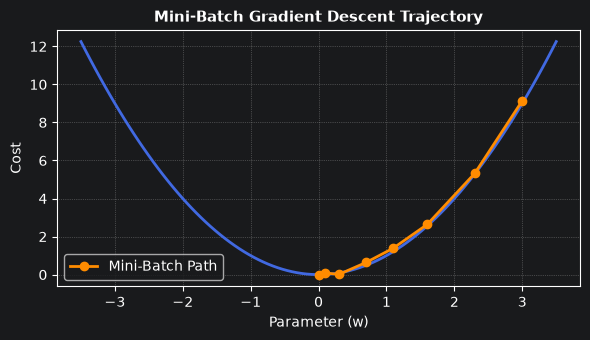

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
# Simulating a moderately smooth path with minor noise
steps_w = np.array([3.0, 2.3, 1.6, 1.1, 0.7, 0.3, 0.1, 0.0])
steps_cost = steps_w ** 2 + np.random.normal(0, 0.08, len(steps_w))

plt.figure(figsize=(6, 3.5))
w = np.linspace(-3.5, 3.5, 100)
plt.plot(w, w**2, color='royalblue', linewidth=2)
plt.plot(steps_w, steps_cost, marker='o', color='darkorange', linestyle='-', linewidth=2, label="Mini-Batch Path")
plt.title("Mini-Batch Gradient Descent Trajectory", fontsize=11, fontweight='bold')
plt.xlabel("Parameter (w)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()